In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import pickle

In [3]:
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

In [4]:
df = pd.read_csv("Combined_dataset_model.csv")
df = pd.get_dummies(df, columns=["biome"], dtype=int)
df = df.drop(columns=['Unnamed: 0'])
print(df.columns)


Index(['county', 'land_area', 'tc_goal', 'treecanopy', 'tc_gap', 'priority_i',
       'pctpocnorm', 'pctpovnorm', 'unemplnorm', 'dep_perc', 'depratnorm',
       'health_nor', 'temp_norm', 'tes', 'tesctyscor', 'rank', 'rankgrpsz',
       'Mean_Temp', 'Median_Temp', 'STD_Temp', 'Min_Temp', 'Max_Temp',
       'Mean_Rain', 'Median_Rain', 'STD_Rain', 'Min_Rain', 'Max_Rain',
       'biome_Desert', 'biome_Forest', 'biome_Grassland'],
      dtype='str')


In [5]:
features = ['land_area', 'treecanopy', 'tc_gap',
       'priority_i', 'pctpocnorm', 'pctpovnorm', 'unemplnorm', 'dep_perc',
       'depratnorm', 'health_nor', 'tes', 'tesctyscor', 'rank',
       'rankgrpsz', 'Mean_Temp', 'Median_Temp', 'STD_Temp', 'Min_Temp',
       'Max_Temp', 'Mean_Rain', 'Median_Rain', 'STD_Rain', 'Min_Rain',
       'Max_Rain']
target = ['temp_norm']
X_df = df[features]
y_df = df[target]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_df, y_df, test_size = 0.2, random_state = 42)

In [7]:
model = XGBRegressor(learning_rate = 0.2, max_depth = 5, n_estimators = 300)
model.fit(X_train, y_train)
model_pred = model.predict(X_test)

print("R2 score:", r2_score(y_test, model_pred))
print("MAE:", mean_absolute_error(y_test, model_pred))




R2 score: 0.7209781408309937
MAE: 0.0701315701007843


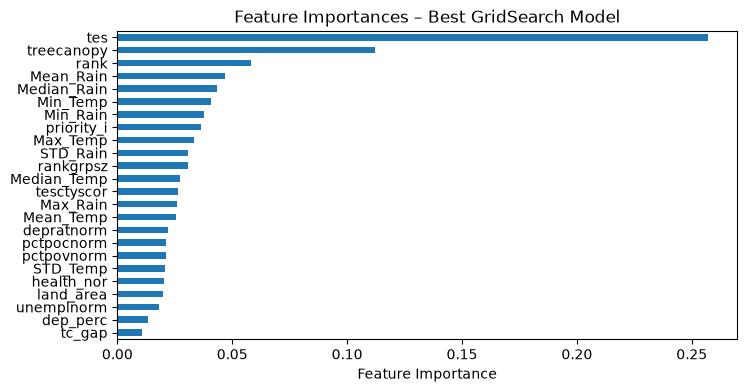

In [8]:
importance = model.feature_importances_
feat_imp = pd.Series(importance, index=features).sort_values()

plt.figure(figsize = (8, 4))
feat_imp.plot(kind = 'barh')
plt.xlabel("Feature Importance")
plt.title("Feature Importances – Best GridSearch Model")
plt.show()


In [9]:
solution_costs = pd.read_csv("Green Intervention Budgets - Sheet1.csv")

In [10]:
# Define what each solution actually changes, and by how much
solution_effects = {
    "green_street": {
        "treecanopy": 1.10,
        "Mean_Temp": 1.15,
        "Cost": int(solution_costs[solution_costs['intervention'] == "Green Street"]['sq_foot_cost_dollars'].iloc[0] * solution_costs[solution_costs['intervention'] == "Green Street"]["avg_sq_feet"].iloc[0])


    },

    "green_parking_lot": {
        "treecanopy": 1.06,
        "Mean_Temp": 1.09,
        "Cost": int(solution_costs[solution_costs['intervention'] == "Green Parking Lot"]['sq_foot_cost_dollars'].iloc[0] * solution_costs[solution_costs['intervention'] == "Green Parking Lot"]["avg_sq_feet"].iloc[0])

    },

    "urban_forest": {
        "treecanopy": 1.2,
        "Mean_Temp": 1.03,
        "Cost": int(solution_costs[solution_costs['intervention'] == "Urban Forest"]['sq_foot_cost_dollars'].iloc[0] * solution_costs[solution_costs['intervention'] == "Urban Forest"]["avg_sq_feet"].iloc[0])

    },

    "green_roof": {
        "treecanopy": 1.05,
        "Mean_Temp": 1.01,
        "Cost": int(solution_costs[solution_costs['intervention'] == "Green Roof"]['sq_foot_cost_dollars'].iloc[0] * solution_costs[solution_costs['intervention'] == "Green Roof"]["avg_sq_feet"].iloc[0])
    },

    "green_belt": {
        "treecanopy": 1.2,
        "Mean_Temp": 1.1,
        "Cost": int(solution_costs[solution_costs['intervention'] == "Green Belt"]['sq_foot_cost_dollars'].iloc[0] * solution_costs[solution_costs['intervention'] == "Green Belt"]["avg_sq_feet"].iloc[0])
    },

    "park": {
        "treecanopy": 1.14,
        "Mean_Temp": 1.01,
        "Cost": int(solution_costs[solution_costs['intervention'] == "Park"]['sq_foot_cost_dollars'].iloc[0] * solution_costs[solution_costs['intervention'] == "Park"]["avg_sq_feet"].iloc[0])
    },

    "garden": {
        "treecanopy": 1.03,
        "Mean_Temp": 1.06,
        "Cost": int(solution_costs[solution_costs['intervention'] == "Garden"]['sq_foot_cost_dollars'].iloc[0] * solution_costs[solution_costs['intervention'] == "Garden"]["avg_sq_feet"].iloc[0])
    }

}

solution_effects = pd.DataFrame(solution_effects)
solution_effects = solution_effects.T
solution_effects.head()

,treecanopy,Mean_Temp,Cost
green_street,1.10,1.15,60000.0
green_parking_lot,1.06,1.09,300000.0
urban_forest,1.20,1.03,500000.0
green_roof,1.05,1.01,200000.0
green_belt,1.20,1.10,750000.0


In [11]:
def impact_calc(model, county, solutions_dict, feature_cols):
  impact_results = [] # To store results
  county_df_filtered = df[df["county"] == county]

  for index, row_data in county_df_filtered.iterrows():
    # Get prediction
    original_features = row_data[feature_cols]
    prediction_original = model.predict(pd.DataFrame([original_features]))[0]

    for solution_name, effects in solutions_dict.iterrows(): # Iterate through solutions and their effects
      modified_features = original_features.copy() # Create a copy to modify
      for key, value in effects.items(): # Apply effects
        if key in modified_features.index:
          modified_features[key] *= value
        #else:
          #print("Warning: Feature", key, "from solution", solution_name, "not found in model features. Skipping update for this feature.")

      # Predict with modified features
      prediction_modified = model.predict(pd.DataFrame([modified_features]))[0]

      # Calculate change
      pct_temp_chg = (prediction_modified - prediction_original) / prediction_original if prediction_original != 0 else 0

      impact_results.append({
          "county": county,
          "row_index": index,
          "solution": solution_name,
          "original_temp_norm_pred": prediction_original,
          "modified_temp_norm_pred": prediction_modified,
          "pct_temp_change": pct_temp_chg
      })
  return impact_results


result = impact_calc(model, "Austin County", solution_effects, features)
pd.DataFrame(result)
result

[{'county': 'Austin County',
  'row_index': 114,
  'solution': 'green_street',
  'original_temp_norm_pred': np.float32(0.4866951),
  'modified_temp_norm_pred': np.float32(0.4204291),
  'pct_temp_change': np.float32(-0.13615505)},
 {'county': 'Austin County',
  'row_index': 114,
  'solution': 'green_parking_lot',
  'original_temp_norm_pred': np.float32(0.4866951),
  'modified_temp_norm_pred': np.float32(0.42726064),
  'pct_temp_change': np.float32(-0.122118495)},
 {'county': 'Austin County',
  'row_index': 114,
  'solution': 'urban_forest',
  'original_temp_norm_pred': np.float32(0.4866951),
  'modified_temp_norm_pred': np.float32(0.45442554),
  'pct_temp_change': np.float32(-0.066303454)},
 {'county': 'Austin County',
  'row_index': 114,
  'solution': 'green_roof',
  'original_temp_norm_pred': np.float32(0.4866951),
  'modified_temp_norm_pred': np.float32(0.50671697),
  'pct_temp_change': np.float32(0.041138396)},
 {'county': 'Austin County',
  'row_index': 114,
  'solution': 'green_be

In [12]:
def impact_calc(model, county, solution_effects, features):
    county_df = df[df["county"] == county]
    final_results = []

    for row_idx, row_data in county_df.iterrows():
        baseline = row_data[features]
        prediction = model.predict(pd.DataFrame([baseline]))[0]

        # Initialize dictionary for the current row
        row_output = {
            "county": county,
            "original_temp": prediction
        }

        for solution_name, effects_series in solution_effects.iterrows():
            modified = baseline.copy()
            for feature_key, multiplier in effects_series.items():
                # Only modify features that are in the model's feature list and are not 'Cost'
                if feature_key in features and feature_key != 'Cost':
                    modified[feature_key] = modified[feature_key] * multiplier

            update_prediction = model.predict(pd.DataFrame([modified]))[0]
            pct_temp_norm_chg = ((update_prediction - prediction) / prediction) * 100 # Calculate percentage change

            # Add solution-specific results as new columns
            row_output[f"{solution_name}_modified_temp"] = update_prediction
            row_output[f"{solution_name}_pct_temp_norm_chg"] = pct_temp_norm_chg

        final_results.append(row_output)

    return pd.DataFrame(final_results)


result = impact_calc(model, "Austin County", solution_effects, features)
display(result)

,county,original_temp,green_street_modified_temp,green_street_pct_temp_norm_chg,green_parking_lot_modified_temp,green_parking_lot_pct_temp_norm_chg,urban_forest_modified_temp,urban_forest_pct_temp_norm_chg,green_roof_modified_temp,green_roof_pct_temp_norm_chg,green_belt_modified_temp,green_belt_pct_temp_norm_chg,park_modified_temp,park_pct_temp_norm_chg,garden_modified_temp,garden_pct_temp_norm_chg
0,Austin County,0.486695,0.420429,-13.615505,0.427261,-12.211849,0.454426,-6.630345,0.506717,4.113840,0.411209,-15.509995,0.512006,5.200500,0.440823,-9.425209
1,Austin County,0.482697,0.421333,-12.712629,0.421333,-12.712629,0.424138,-12.131557,0.465272,-3.609873,0.414779,-14.070550,0.465272,-3.609873,0.429521,-11.016306
2,Austin County,0.488513,0.441314,-9.661875,0.441314,-9.661875,0.461411,-5.547961,0.509232,4.241118,0.438308,-10.277250,0.509232,4.241118,0.449502,-7.985749
3,Austin County,0.499661,0.395348,-20.876759,0.395348,-20.876759,0.416484,-16.646708,0.440010,-11.938230,0.401466,-19.652201,0.443904,-11.158889,0.396135,-20.719259
4,Austin County,0.376860,0.326953,-13.242839,0.335202,-11.053856,0.353288,-6.254929,0.396589,5.235168,0.321546,-14.677630,0.382933,1.611394,0.352130,-6.562252
5,Austin County,0.544964,0.524729,-3.713112,0.525134,-3.638825,0.516265,-5.266260,0.564393,3.565260,0.506650,-7.030531,0.545910,0.173554,0.513489,-5.775634
6,Austin County,0.477214,0.427551,-10.406865,0.427551,-10.406865,0.429509,-9.996501,0.459154,-3.784394,0.427551,-10.406865,0.459154,-3.784394,0.428972,-10.108969


In [13]:
costs = [c for c in solution_effects['Cost']]
costs

[60000.0, 300000.0, 500000.0, 200000.0, 750000.0, 750000.0, 40000.0]

In [17]:
from ortools.sat.python import cp_model

# Precomputed from XGBoost model.predict() for each candidate
costs = [c for c in solution_effects['Cost']]
total_cost = 0
budget  = 1200000
final_results = pd.DataFrame(columns = ["county", "green_streets", "green_parking_lots", 
                                        "urban_forests", "green_roofs", "green_belts", 
                                        "parks", "gardens", "total_impact", "total_cost"])

# make it maximize impacts, not tree canopy
# predicted health impact
for index, row in result.iterrows():
  baseline = row
  temp_changes = {
      "gstreet": baseline['green_street_pct_temp_norm_chg'], 
      "gparklot": baseline['green_parking_lot_pct_temp_norm_chg'], 
      "urbforest": baseline['urban_forest_pct_temp_norm_chg'],
      "groof": baseline['green_roof_pct_temp_norm_chg'],
      "gbelt": baseline['green_belt_pct_temp_norm_chg'],
      "park": baseline['park_pct_temp_norm_chg'],
      "garden": baseline['garden_pct_temp_norm_chg']
  }
  model_cp = cp_model.CpModel()

  gstreet = model_cp.new_int_var(0, 5, "gstreet")
  gparklot = model_cp.new_int_var(0, 5, "gparklot")
  urbforest = model_cp.new_int_var(0, 5, "urbforest")
  groof = model_cp.new_int_var(0, 5, "groof")
  gbelt = model_cp.new_int_var(0, 5, "gbelt")
  park = model_cp.new_int_var(0, 5, "park")
  garden = model_cp.new_int_var(0, 5, "garden")

  model_cp.Add(
     gstreet * int(costs[0]) +
     gparklot * int(costs[1]) +
     urbforest * int(costs[2]) +
     groof * int(costs[3]) +
     gbelt * int(costs[4]) +
     park * int(costs[5]) +
     garden * int(costs[6])
     <= budget
  )
  model_cp.Minimize(
     gstreet * temp_changes["gstreet"] +
     gparklot * temp_changes["gparklot"] +
     urbforest * temp_changes["urbforest"] +
     groof * temp_changes["groof"] +
     gbelt * temp_changes["gbelt"] +
     park * temp_changes["park"] +
     garden * temp_changes["garden"]
  )

  solver = cp_model.CpSolver()
  status = solver.Solve(model_cp) # Corrected to use model_cp

  if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
    final_results = pd.concat([final_results, pd.DataFrame({
      "county": [baseline['county']],
      "green_streets": [solver.Value(gstreet)],
      "green_parking_lots": [solver.Value(gparklot)],
      "urban_forests": [solver.Value(urbforest)],
      "green_roofs": [solver.Value(groof)],
      "green_belts": [solver.Value(gbelt)],
      "parks": [solver.Value(park)],
      "gardens": [solver.Value(garden)],
      "total_impact": [solver.ObjectiveValue()],
      "total_cost": [solver.Value(
        gstreet * int(costs[0]) +
        gparklot * int(costs[1]) +
        urbforest * int(costs[2]) +
        groof * int(costs[3]) +
        gbelt * int(costs[4]) +
        park * int(costs[5]) +
        garden * int(costs[6]))]
    })])
  elif status == cp_model.INFEASIBLE:
    print("No solution found that satisfies the constraints.")
  else:
    print("Solver could not find an optimal or feasible solution.")

final_results 

,county,green_streets,green_parking_lots,urban_forests,green_roofs,green_belts,parks,gardens,total_impact,total_cost
0,Austin County,5,2,0,0,0,0,5,-139.62727,1100000
0,Austin County,5,2,0,0,0,0,5,-144.069935,1100000
0,Austin County,5,2,0,0,0,0,5,-107.56187,1100000
0,Austin County,5,1,0,2,0,0,5,-252.733307,1200000
0,Austin County,5,2,0,0,0,0,5,-121.133164,1100000
0,Austin County,5,2,0,0,0,0,5,-54.721377,1100000
0,Austin County,5,2,0,0,0,0,5,-123.3929,1100000
